# Import Packages

We'll make use of the following packages:
- `numpy` is a package for scientific computing in python.
- `pandas` A powerful Python library for data manipulation and analysis.
- `seaborn` A data visualization library based on matplotlib.
- `scikit-learn` A comprehensive library for machine learning in Python.
- `kaggle` Using Kaggle API to download data.

In [176]:
import pandas as pd
import numpy as np
import seaborn as sns
import kagglehub
import os
import math
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import logging
import importlib
import src.data_preprocessing
import src.eda
importlib.reload(src.data_preprocessing)
importlib.reload(src.eda)
from src.data_preprocessing import DataPreprocessor
from src.eda import NumericalEDA, CategoricalEDA
from typing import List, Optional, Union




# Download Data

In [3]:
# Download latest version
path = kagglehub.dataset_download("taeefnajib/used-car-price-prediction-dataset")

print(os.listdir(path))

['used_cars.csv']


In [19]:
## 
assets_dir = os.path.join('.', "assets")


## Check data

In [20]:
## Check data
df = pd.read_csv(os.path.join(path, "used_cars.csv"))

# Data Preprocessing via pipeline

In [38]:
# Data Preprocessing via pipeline
dp = DataPreprocessor(df,assets_dir=assets_dir)
df_new = dp.preprocess()

COMPLETE: rename_column. -
 {'milage': 'mileage'}
No missing values found.
Data preprocessing completed successfully.


# EDA

In [151]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                4009 non-null   object 
 1   model                4009 non-null   object 
 2   model_year           4009 non-null   int64  
 3   mileage              4009 non-null   float64
 4   fuel_type            4009 non-null   object 
 5   engine               4009 non-null   object 
 6   transmission         4009 non-null   object 
 7   ext_col              4009 non-null   object 
 8   int_col              4009 non-null   object 
 9   accident             4009 non-null   object 
 10  clean_title          4009 non-null   int64  
 11  price                4009 non-null   float64
 12  transmission_type    4009 non-null   object 
 13  transmission_speeds  4009 non-null   float64
 14  hp                   4009 non-null   float64
 15  liters               4009 non-null   f

Column names and new features are showing as expected.

In [45]:
df_eda = df_new[['brand', 'model', 'model_year', 'mileage', 'fuel_type',
                'clean_title','transmission_type', 'transmission_speeds', 
                'hp', 'liters','cylinders', 'ext_color_std', 'int_col_std', 
                'accident_reported', 'price']]

In [46]:
df_eda.head()

,brand,model,model_year,mileage,fuel_type,clean_title,transmission_type,transmission_speeds,hp,liters,cylinders,ext_color_std,int_col_std,accident_reported,price
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,1,Automatic,6.0,300.0,3.7,6.0,black,black,1,10300.0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,1,Automatic,8.0,291.0,3.8,6.0,blue,gray,1,38005.0
2,Lexus,RX 350,2022,22372.0,Gasoline,0,Automatic,8.0,295.0,3.5,6.0,blue,black,0,54598.0
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,1,Automatic,7.0,354.0,3.5,6.0,black,black,0,15500.0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,0,Automatic,8.0,228.0,2.0,4.0,white,black,0,34999.0


### Numerical Histogram

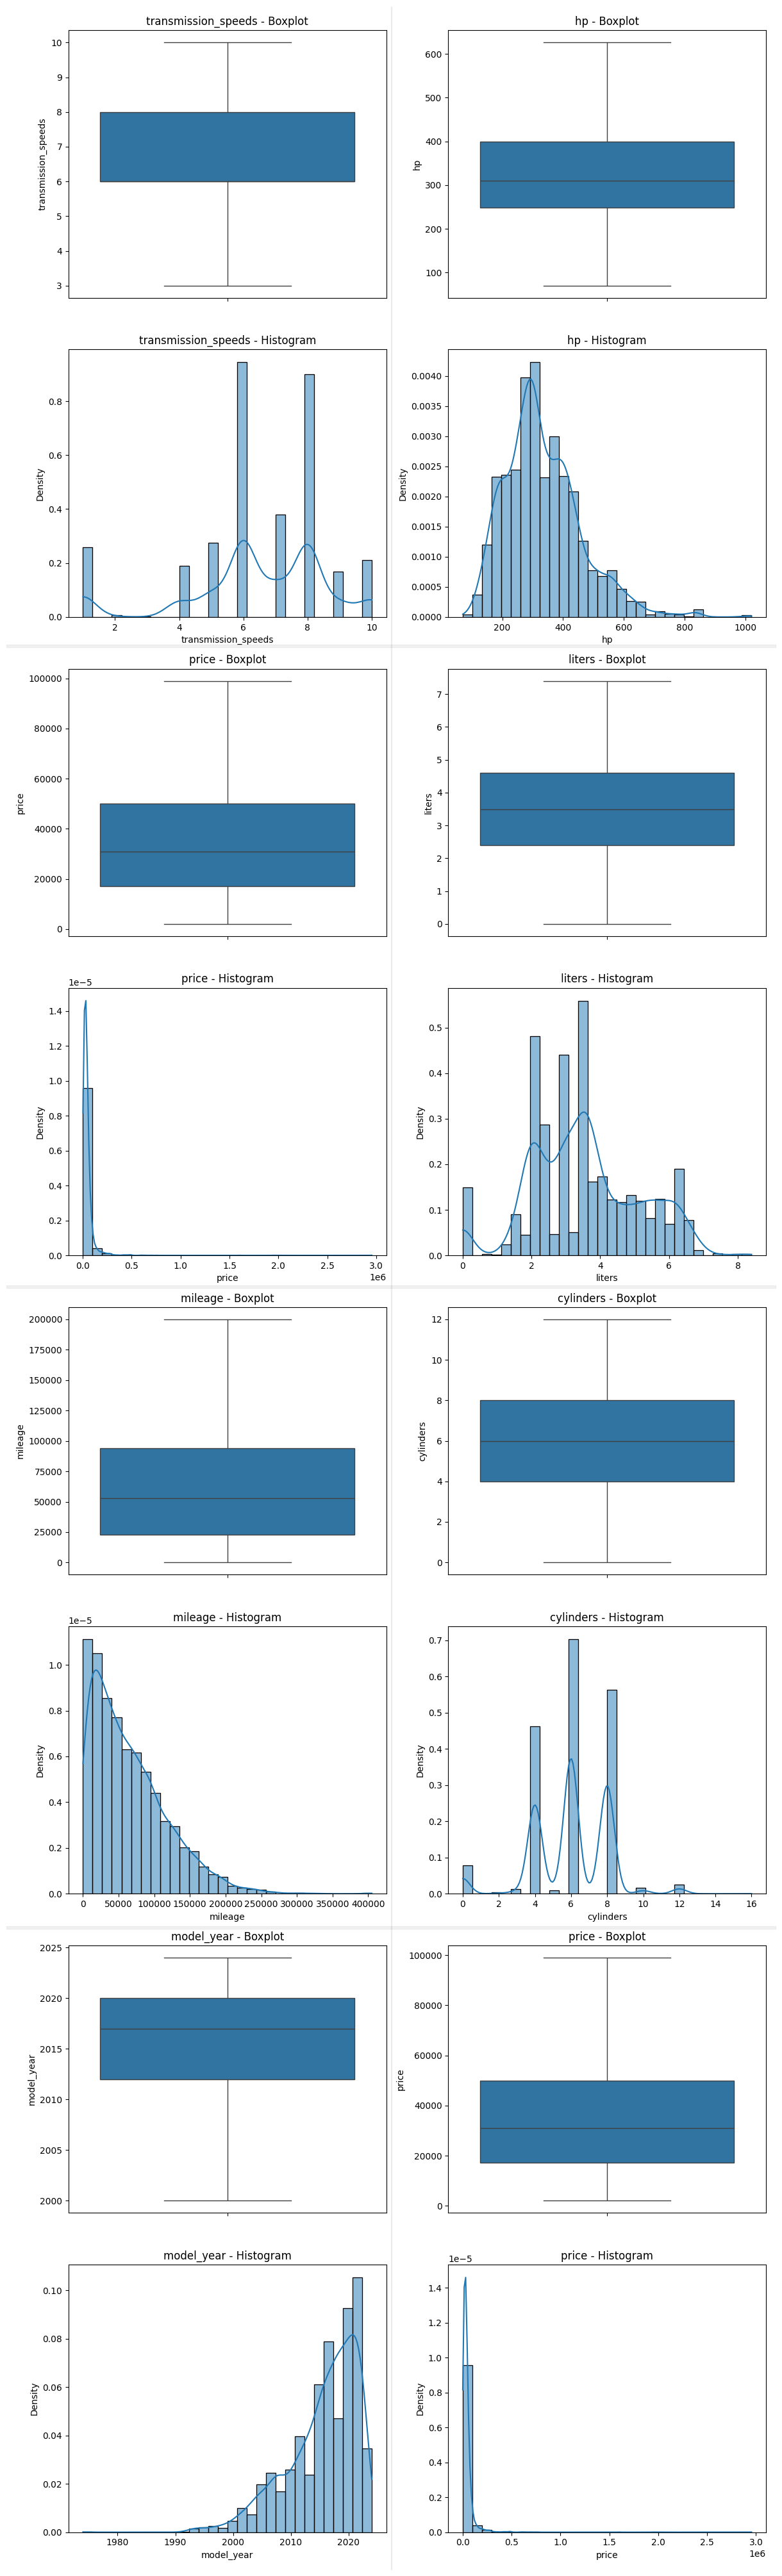

In [177]:
cat_cols = ['brand', 'model', 'fuel_type', 'clean_title','transmission_type','ext_color_std', 'int_col_std', 'accident_reported']
target = 'price'

numericaleda = NumericalEDA(df_eda, cat_cols=cat_cols, target_col=target)
numericaleda.plot_box_and_hist_per_feature()

📈 **Numerical Feature Distribution Analysis**

⚠️ Most numerical features show **strong right-skew** in their distributions—especially `price`, which has a massive high-value tail, likely due to supercars and exotics in the dataset.

- The same pattern appears in `mileage`.
- Even features like `hp`, `cylinders`, and `liters` are *nowhere near* normally distributed.

**Takeaway:**  
These features need normalization or transformation (log-scale, robust scaling, etc.) for machine learning models to work properly. If you skip this, you’re just feeding garbage into your model and expecting gold out of it.

---

## Categorical Bar Plot

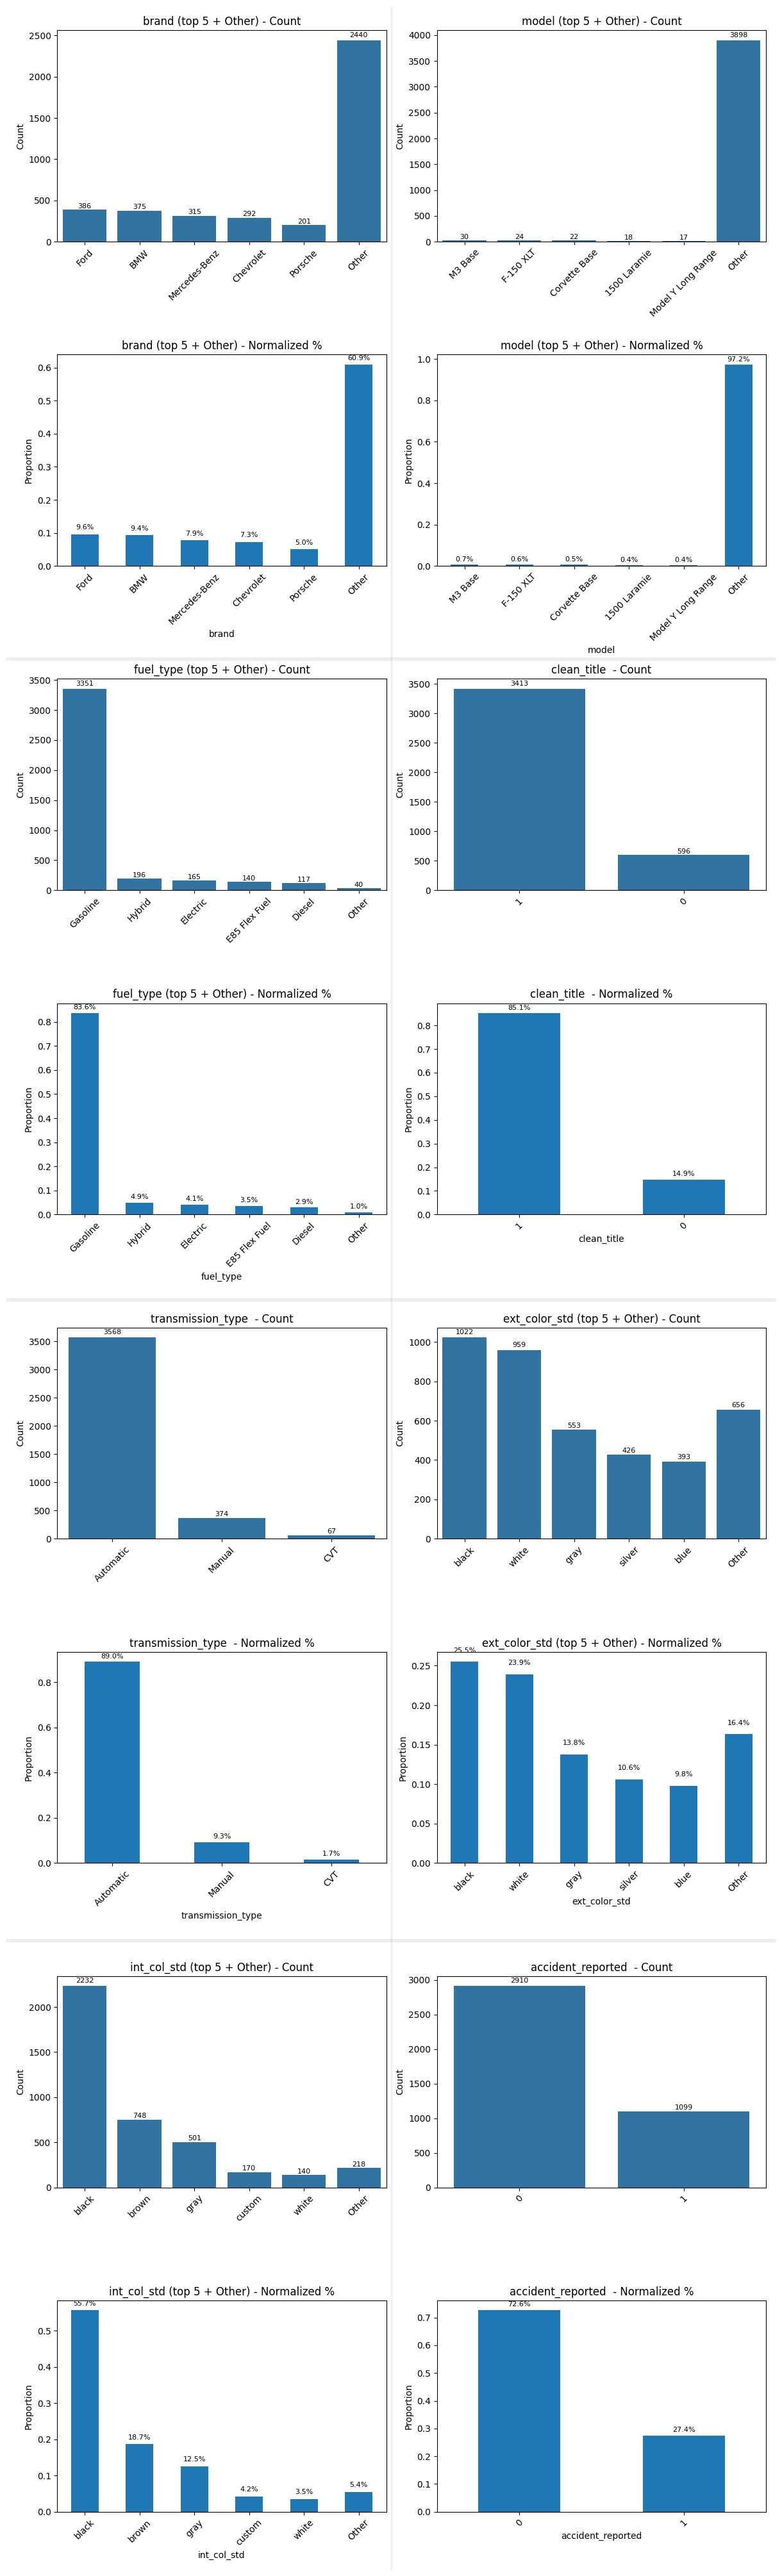

In [178]:
cat_eda = CategoricalEDA(dataframe=df_eda, cat_cols=cat_cols)
cat_eda.plot_bar_and_normalized_bars()

🏷️ **Categorical Feature Distribution Analysis**

**Brand and Model:**  
Most brands and models have *very* few cars in the dataset—a classic long-tail problem. Only a handful of brands make up the bulk of the records, while most individual models are practically unicorns.

**Other Categorical Features:**  
Distributions are heavily unbalanced—one or two categories (like “automatic” transmission or “clean title”) absolutely dominate, with the rest barely registering.

**Takeaway:**  
The data is *very* imbalanced across both brands/models and most categorical features. Any downstream modeling—classification, stratified splitting, evaluation—needs to keep this in mind to avoid skewed, unreliable results.

---

## Correlation


📊 Plotting Correlation Matrix of Numerical Features...


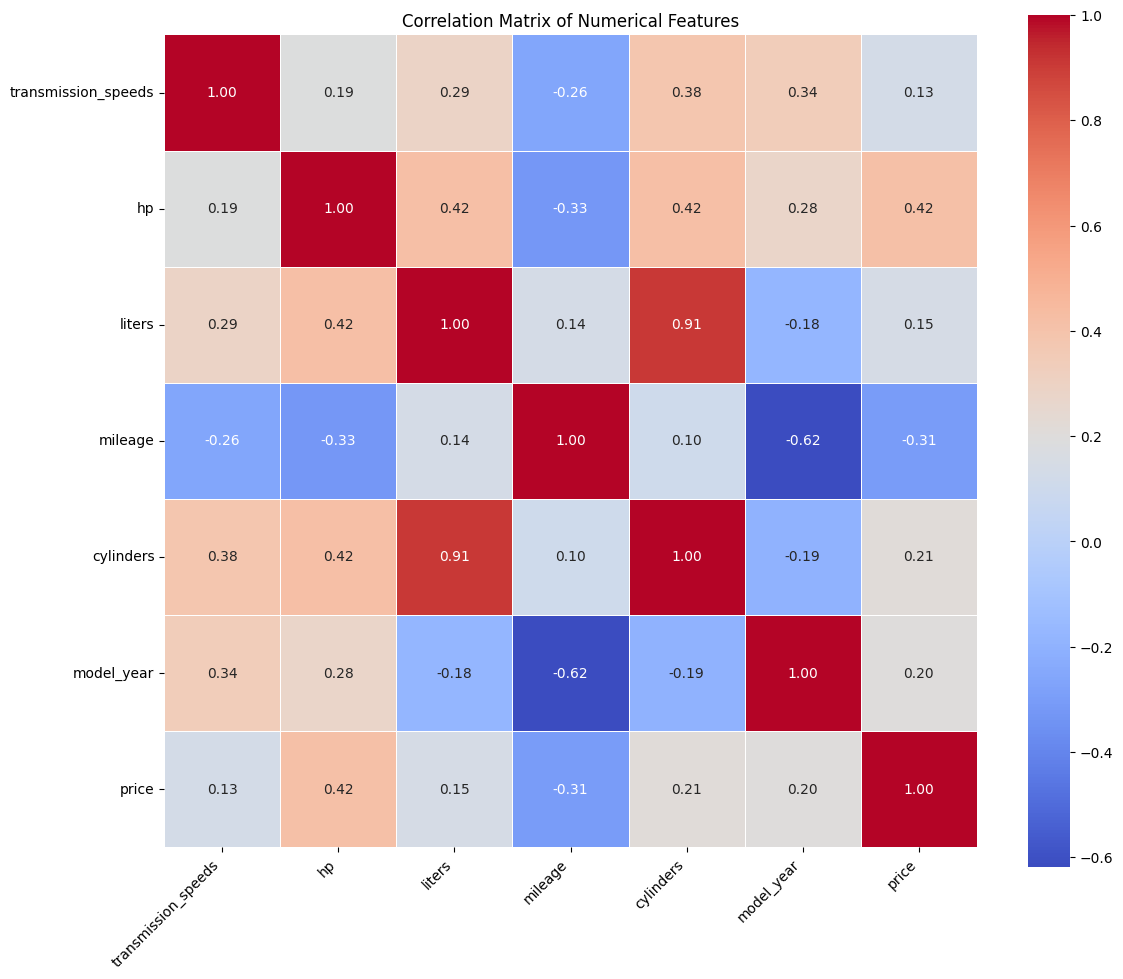

In [179]:
numericaleda.plot_corr_heat_map()

🧊 **Correlation Matrix Interpretation**

The correlation matrix provides a clear look at the linear relationships among the key numerical features of the dataset. Here’s what stands out:

- **Target Relationship:**  
  - Most features show relatively weak correlation with `price`, except for `hp` (horsepower), which stands out as the most positively correlated. This makes sense: cars with higher horsepower are usually positioned as premium models with higher prices.
  - `mileage` is negatively correlated with `price`, reflecting the reality that cars with higher mileage typically fetch lower resale values.

- **Feature-to-Feature Patterns:**  
  - `hp`, `cylinders`, and `liters` show strong mutual correlation—unsurprising, since they all describe engine characteristics. A car with more cylinders almost always packs a bigger engine (more liters) and puts out more horsepower.
  - There’s a notable negative correlation between `model_year` and `mileage`. Newer cars (higher model_year) haven’t had as much time to rack up miles.
  - `liters` and `cylinders` are highly correlated, so if model simplicity is a concern, one could be dropped or regularized to avoid multicollinearity.

- **Why This Matters:**  
  - This matrix helps identify redundant features, guides feature selection, and validates whether model outputs are in line with what I know about cars.  
  - If my model starts suggesting that higher mileage increases price, or that engine size doesn’t matter, I’ll know the model’s not working well and needs fixing.
  - These insights directly inform feature engineering and model debugging for robust, interpretable ML.

---
